# Temperature-data sparsity

Does the Van't Hoff bias reduce how many measured temperatures each
solute-solvent pair needs?

This differs from the T-extrapolation split. Model A has to learn the
temperature response from examples; model Bc is given the functional form and
predicts `(a, beta)` from chemistry. An inductive bias should be worth most when
data are scarce, so the test is whether Bc needs fewer temperatures per pair
than A to reach comparable accuracy.

Both stay global models trained across all pairs - no per-pair Van't Hoff line
is fitted. Only the number of temperatures retained per pair changes.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))

from train import RES, train_one, metrics_row, load_features   # frozen loop
from prepare_b_scale import per_pair_slopes                    # training-only slope fits

X_desc, T_arr, y, pair_id = load_features()
T_arr = T_arr.astype(np.float64)
y = y.astype(np.float64)

print(f"measurements: {len(y):,}   pairs: {len(np.unique(pair_id)):,}")
print(f"T range: {T_arr.min():.1f} - {T_arr.max():.1f} K")

measurements: 100,983   pairs: 10,855
T range: 243.1 - 425.8 K


## Eligible pairs

A pair is usable only if it has enough *distinct* temperatures to both train on
a sparse subset and still leave held-out temperatures to score.

Our design (section 3) reserves 2 temperatures per pair for testing, so the
training pool has `n_distinct_T - 2` temperatures. To make `n_T = 3` and
`n_T = all` genuinely different conditions, every pair needs a pool of at
least 4.

In [2]:
pairs = pd.DataFrame({"pair_id": pair_id, "T": T_arr}).groupby("pair_id")["T"]
n_distinct = pairs.nunique()
n_rows = pairs.size()

for k in (4, 5, 6, 7):
    sel = n_distinct >= k
    print(f">= {k} distinct T: {sel.sum():6,} pairs   "
          f"{n_rows[sel].sum():7,} rows   pool = n_T-2 >= {k-2}")

>= 4 distinct T: 10,488 pairs   100,570 rows   pool = n_T-2 >= 2
>= 5 distinct T: 10,405 pairs   100,238 rows   pool = n_T-2 >= 3
>= 6 distinct T:  9,242 pairs    94,259 rows   pool = n_T-2 >= 4
>= 7 distinct T:  8,806 pairs    91,613 rows   pool = n_T-2 >= 5


**Choice: `>= 6` distinct temperatures.**

- `>= 4` and `>= 5` leave pools of 2 and 3. With a pool of 3, `n_T = 3` *is*
  "all" for those pairs, so the two sparsest-versus-densest conditions stop
  being distinguishable.
- `>= 6` guarantees a pool of at least 4, so "all" is strictly denser than
  `n_T = 3` for **every** pair, while still keeping 9,242 pairs (85 % of them).
- `>= 7` would cost another 400 pairs for no design benefit.

In [3]:
MIN_DISTINCT_T = 6
eligible = set(n_distinct[n_distinct >= MIN_DISTINCT_T].index.tolist())

rows = pd.DataFrame({"row": np.arange(len(y)), "pair_id": pair_id, "T": T_arr})
rows = rows[rows.pair_id.isin(eligible)].reset_index(drop=True)

print(f"eligible pairs: {len(eligible):,}")
print(f"rows belonging to eligible pairs: {len(rows):,}")

eligible pairs: 9,242
rows belonging to eligible pairs: 94,259


## Constructing the sparse training sets

Per eligible pair:

1. **Fixed test temperatures** (identical in every condition, chosen once with
   seed 0 and never re-drawn):
   - the pair's **highest** temperature — guarantees an extrapolation target;
   - one **interior** temperature — an interpolation target.
2. **Pool** = the pair's remaining temperatures.
3. For `n_T in {1, 2, 3, all}`, sample `n_T` temperatures from the pool and keep
   *all rows measured at those temperatures* as training data.

The test rows are fixed before any training temperature is chosen, so held-out
data never influences the selection. Sampling is repeated with 3 temperature
seeds so no single arbitrary draw drives the result.

In [4]:
TEST_SEED = 0
rng = np.random.default_rng(TEST_SEED)

test_rows, pool_temps = [], {}
for pid, g in rows.groupby("pair_id"):
    temps = np.sort(g["T"].unique())
    t_hi = temps[-1]                                  # extrapolation target
    t_mid = rng.choice(temps[1:-1])                   # interpolation target
    test_rows.append(g[g["T"].isin([t_hi, t_mid])]["row"].to_numpy())
    pool_temps[pid] = temps[(temps != t_hi) & (temps != t_mid)]

test_idx = np.sort(np.concatenate(test_rows))
pool_sizes = np.array([len(v) for v in pool_temps.values()])

print(f"fixed test rows: {len(test_idx):,}")
print(f"pool size per pair: min {pool_sizes.min()}, median {int(np.median(pool_sizes))}, max {pool_sizes.max()}")

fixed test rows: 19,019
pool size per pair: min 4, median 7, max 48


In [5]:
def build_train_rows(n_T, sample_seed):
    """Row indices kept for training at this temperature budget.

    n_T is an int, or "all" to use the whole pool. Returns sorted indices;
    never includes a test row.
    """
    rs = np.random.default_rng(1000 + sample_seed)
    keep = []
    for pid, g in rows.groupby("pair_id"):
        pool = pool_temps[pid]
        picked = pool if n_T == "all" else rs.choice(pool, size=n_T, replace=False)
        keep.append(g[g["T"].isin(picked)]["row"].to_numpy())
    keep = np.sort(np.concatenate(keep))
    return np.setdiff1d(keep, test_idx)


N_T_LEVELS = [1, 2, 3, "all"]
SAMPLE_SEEDS = [0, 1, 2]

train_sets = {(n, s): build_train_rows(n, s) for n in N_T_LEVELS for s in SAMPLE_SEEDS}

summary = pd.DataFrame([
    {"n_T": str(n), "sample_seed": s, "train_rows": len(train_sets[(n, s)])}
    for n in N_T_LEVELS for s in SAMPLE_SEEDS
])
summary.pivot(index="n_T", columns="sample_seed", values="train_rows")

sample_seed,0,1,2
n_T,,,
1,9573,9576,9569
2,19165,19147,19131
3,28725,28724,28740
all,75240,75240,75240


### Sanity checks

Three things must hold: no training row is ever a test row, the retained
temperatures per pair match the budget, and the test set is identical across
all conditions.

In [6]:
for (n, s), tr in train_sets.items():
    assert len(np.intersect1d(tr, test_idx)) == 0, f"train/test overlap at n_T={n}, seed {s}"

# retained distinct temperatures per pair, at the sparsest and densest budgets
for n in [1, 2, 3, "all"]:
    tr = train_sets[(n, 0)]
    counts = rows[rows.row.isin(tr)].groupby("pair_id")["T"].nunique()
    print(f"n_T={str(n):>3}: pairs covered {len(counts):,}   "
          f"distinct T per pair: min {counts.min()}, median {int(counts.median())}, max {counts.max()}")

print(f"\ntest rows fixed across conditions: {len(test_idx):,} (single array reused everywhere)")

n_T=  1: pairs covered 9,242   distinct T per pair: min 1, median 1, max 1
n_T=  2: pairs covered 9,242   distinct T per pair: min 2, median 2, max 2
n_T=  3: pairs covered 9,242   distinct T per pair: min 3, median 3, max 3
n_T=all: pairs covered 9,242   distinct T per pair: min 4, median 7, max 48

test rows fixed across conditions: 19,019 (single array reused everywhere)


## Evaluation design

Every condition is scored on the **same** held-out rows. Each test row is then
labelled relative to the temperatures that pair actually contributed to
training in that condition:

- **interpolation** — test T lies inside `[min, max]` of the pair's retained
  training temperatures;
- **extrapolation** — test T lies outside that range.

The labels therefore change with `n_T`, which is the honest thing to do: at
`n_T = 1` a pair has a single training temperature and *cannot* bracket
anything, so essentially all of its test rows are extrapolation. Interpolation
and extrapolation are always reported separately.

In [7]:
def label_test_rows(train_idx):
    """Split test rows into (interp_mask, extrap_mask) for one training set."""
    tr = rows[rows.row.isin(train_idx)].groupby("pair_id")["T"].agg(["min", "max"])
    te = rows[rows.row.isin(test_idx)].sort_values("row")
    lo = te["pair_id"].map(tr["min"]).to_numpy()
    hi = te["pair_id"].map(tr["max"]).to_numpy()
    inside = (te["T"].to_numpy() >= lo) & (te["T"].to_numpy() <= hi)
    inside = np.where(np.isnan(lo), False, inside)      # pair absent from training
    return inside, ~inside


for n in N_T_LEVELS:
    ins, ext = label_test_rows(train_sets[(n, 0)])
    print(f"n_T={str(n):>3}: interpolation rows {ins.sum():6,}   extrapolation rows {ext.sum():6,}")

n_T=  1: interpolation rows      0   extrapolation rows 19,019
n_T=  2: interpolation rows  3,608   extrapolation rows 15,411
n_T=  3: interpolation rows  5,431   extrapolation rows 13,588
n_T=all: interpolation rows  8,277   extrapolation rows 10,742


### `b_scale` under sparsity

`b_scale` is fitted from the sparse training rows only, as the median `|b|` of
per-pair OLS fits requiring 2 distinct temperatures per pair.

**At `n_T = 1` this is not estimable**: one temperature per pair carries no
slope information at all. In that single condition we fall back to the project's
frozen constant, 1382 K. Section 8 measures how much that choice matters — it
turns out not to be negligible at `n_T = 1`, which is itself informative.

In [8]:
B_SCALE_FALLBACK = 1382.0

def fit_b_scale(train_idx):
    """Median |b| over training rows only; None if not estimable."""
    slopes, _, _ = per_pair_slopes(T_arr, y, pair_id, train_idx,
                                   min_rows=2, min_distinct_T=2)
    if len(slopes) == 0:
        return None, 0
    return float(np.median(np.abs(slopes))), len(slopes)


for n in N_T_LEVELS:
    bs, n_pairs = fit_b_scale(train_sets[(n, 0)])
    shown = f"{bs:.1f} K from {n_pairs:,} pairs" if bs else f"not estimable -> fallback {B_SCALE_FALLBACK:.0f} K"
    print(f"n_T={str(n):>3}: b_scale {shown}")

n_T=  1: b_scale not estimable -> fallback 1382 K
n_T=  2: b_scale 1361.5 K from 9,242 pairs


n_T=  3: b_scale 1370.1 K from 9,242 pairs


n_T=all: b_scale 1370.5 K from 9,242 pairs


In [9]:
MODEL_SEEDS = [42, 123, 456]
OUT_CSV = RES / "metrics_temperature_sparsity.csv"


def split_indices(train_idx, seed):
    """90/10 train/val over the retained rows; test is the fixed held-out set."""
    rs = np.random.default_rng(seed)
    perm = rs.permutation(len(train_idx))
    n_val = int(round(0.10 * len(train_idx)))
    return np.sort(train_idx[perm[n_val:]]), np.sort(train_idx[perm[:n_val]]), test_idx


def load_done(path):
    if not path.exists():
        return set()
    d = pd.read_csv(path)
    return {(str(r.model), str(r.n_T), int(r.sample_seed), int(r.model_seed)) for r in d.itertuples()}


def append_row(path, row):
    df = pd.DataFrame([row])
    if path.exists():
        df = pd.concat([pd.read_csv(path), df], ignore_index=True)
    df.to_csv(path, index=False)

In [10]:
import time

done = load_done(OUT_CSV)
t0 = time.time()

for n in N_T_LEVELS:
    for s in SAMPLE_SEEDS:
        tr_rows = train_sets[(n, s)]
        bs_fit, _ = fit_b_scale(tr_rows)
        b_scale = bs_fit if bs_fit is not None else B_SCALE_FALLBACK
        ins, ext = label_test_rows(tr_rows)
        print(f"\n--- n_T={n}  sample_seed={s}  train_rows={len(tr_rows):,}  "
              f"b_scale={b_scale:.1f} K  interp/extrap={ins.sum():,}/{ext.sum():,}")
        for kind in ["A", "Bc"]:
            for ms in MODEL_SEEDS:
                if (kind, str(n), s, ms) in done:
                    print(f"    [cached] {kind} seed {ms}")
                    continue
                idx = split_indices(tr_rows, seed=s)
                metrics, elapsed, preds = train_one(
                    kind, f"tsparse_n{n}_s{s}", ms, device="cpu",
                    b_scale=(b_scale if kind == "Bc" else None),
                    verbose=False, split_indices=idx,
                )
                err = preds["y_pred"] - preds["y_true"]
                row = {
                    "model": kind, "n_T": str(n), "sample_seed": s, "model_seed": ms,
                    "train_rows": len(idx[0]), "val_rows": len(idx[1]), "test_rows": len(idx[2]),
                    "b_scale": b_scale if kind == "Bc" else None,
                    "test_rmse": metrics["test"]["rmse"],
                    "test_mae": metrics["test"]["mae"],
                    "rmse_interp": float(np.sqrt(np.mean(err[ins] ** 2))) if ins.sum() else np.nan,
                    "rmse_extrap": float(np.sqrt(np.mean(err[ext] ** 2))) if ext.sum() else np.nan,
                    "n_interp": int(ins.sum()), "n_extrap": int(ext.sum()),
                    "elapsed_s": round(elapsed, 1),
                }
                append_row(OUT_CSV, row)
                print(f"    {kind:>2} seed {ms}: test_rmse={row['test_rmse']:.4f}  "
                      f"interp={row['rmse_interp']:.4f}  extrap={row['rmse_extrap']:.4f}  ({elapsed:.0f}s)")

print(f"\nsweep wall time: {(time.time() - t0) / 60:.1f} min")


--- n_T=1  sample_seed=0  train_rows=9,573  b_scale=1382.0 K  interp/extrap=0/19,019
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456

--- n_T=1  sample_seed=1  train_rows=9,576  b_scale=1382.0 K  interp/extrap=0/19,019
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456

--- n_T=1  sample_seed=2  train_rows=9,569  b_scale=1382.0 K  interp/extrap=0/19,019
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=2  sample_seed=0  train_rows=19,165  b_scale=1361.5 K  interp/extrap=3,608/15,411
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=2  sample_seed=1  train_rows=19,147  b_scale=1371.5 K  interp/extrap=3,693/15,326
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=2  sample_seed=2  train_rows=19,131  b_scale=1370.0 K  interp/extrap=3,685/15,334
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=3  sample_seed=0  train_rows=28,725  b_scale=1370.1 K  interp/extrap=5,431/13,588
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=3  sample_seed=1  train_rows=28,724  b_scale=1370.9 K  interp/extrap=5,556/13,463
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=3  sample_seed=2  train_rows=28,740  b_scale=1369.1 K  interp/extrap=5,514/13,505
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=all  sample_seed=0  train_rows=75,240  b_scale=1370.5 K  interp/extrap=8,277/10,742
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=all  sample_seed=1  train_rows=75,240  b_scale=1370.5 K  interp/extrap=8,277/10,742
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456



--- n_T=all  sample_seed=2  train_rows=75,240  b_scale=1370.5 K  interp/extrap=8,277/10,742
    [cached] A seed 42
    [cached] A seed 123
    [cached] A seed 456
    [cached] Bc seed 42
    [cached] Bc seed 123
    [cached] Bc seed 456

sweep wall time: 0.0 min


## Results

Aggregated over 3 temperature-subsampling seeds x 3 model seeds (9 runs per
model per condition).

In [11]:
res = pd.read_csv(OUT_CSV).drop_duplicates(["model", "n_T", "sample_seed", "model_seed"], keep="last")
order = ["1", "2", "3", "all"]

def table(metric):
    piv = res.pivot_table(index="n_T", columns="model", values=metric, aggfunc=["mean", "std"])
    out = pd.DataFrame({
        "A": piv[("mean", "A")].round(4).astype(str) + " ± " + piv[("std", "A")].round(4).astype(str),
        "Bc": piv[("mean", "Bc")].round(4).astype(str) + " ± " + piv[("std", "Bc")].round(4).astype(str),
        "Bc - A": (piv[("mean", "Bc")] - piv[("mean", "A")]).round(4),
    })
    return out.reindex(order)

print("Held-out-temperature RMSE (all test rows)")
display(table("test_rmse"))

Held-out-temperature RMSE (all test rows)


,A,Bc,Bc - A
n_T,,,
1,0.374 ± 0.0325,0.3856 ± 0.0198,0.0116
2,0.271 ± 0.0107,0.2604 ± 0.0044,-0.0106
3,0.2408 ± 0.0071,0.2364 ± 0.0093,-0.0044
all,0.2049 ± 0.0098,0.1986 ± 0.006,-0.0063


In [12]:
print("Extrapolation-only RMSE (test T outside the pair's training range)")
display(table("rmse_extrap"))

print("\nInterpolation-only RMSE (test T inside the pair's training range)")
display(table("rmse_interp"))

Extrapolation-only RMSE (test T outside the pair's training range)


,A,Bc,Bc - A
n_T,,,
1,0.374 ± 0.0325,0.3856 ± 0.0198,0.0116
2,0.28 ± 0.0112,0.2682 ± 0.0038,-0.0118
3,0.2514 ± 0.0075,0.2445 ± 0.0091,-0.0069
all,0.2229 ± 0.0097,0.2131 ± 0.0059,-0.0098



Interpolation-only RMSE (test T inside the pair's training range)


,A,Bc,Bc - A
n_T,,,
1,NaN,NaN,NaN
2,0.2293 ± 0.0162,0.2246 ± 0.0153,-0.0047
3,0.2125 ± 0.007,0.2151 ± 0.0105,0.0027
all,0.1787 ± 0.0103,0.1779 ± 0.007,-0.0008


### Matched-seed differences

Each `Bc - A` below pairs the two models trained on the *same* retained rows
with the *same* model seed, so the difference is not contaminated by which
temperatures were drawn.

In [13]:
paired = res.pivot_table(index=["n_T", "sample_seed", "model_seed"],
                         columns="model", values="test_rmse").reset_index()
paired["diff"] = paired["Bc"] - paired["A"]

pd.DataFrame({
    "mean Bc-A": paired.groupby("n_T")["diff"].mean().round(4),
    "std": paired.groupby("n_T")["diff"].std().round(4),
    "Bc better (of 9)": paired.groupby("n_T")["diff"].apply(lambda v: int((v < 0).sum())),
}).reindex(order)

,mean Bc-A,std,Bc better (of 9)
n_T,,,
1,0.0116,0.0298,3
2,-0.0106,0.0106,8
3,-0.0044,0.0157,6
all,-0.0063,0.0127,6


### Where the variability comes from

Two sources are deliberately kept separate: which temperatures were drawn
(`sample_seed`) and network initialisation (`model_seed`).

In [14]:
var = []
for n in order:
    sub = res[res.n_T == n]
    for kind in ["A", "Bc"]:
        k = sub[sub.model == kind]
        var.append({
            "n_T": n, "model": kind,
            "std across sample seeds": round(k.groupby("sample_seed")["test_rmse"].mean().std(), 4),
            "std across model seeds": round(k.groupby("model_seed")["test_rmse"].mean().std(), 4),
        })
pd.DataFrame(var).set_index(["n_T", "model"])

std across sample seeds  std across model seeds
n_T model                                                 
1   A                       0.0126                  0.0105
    Bc                      0.0093                  0.0179
2   A                       0.0024                  0.0118
    Bc                      0.0038                  0.0007
3   A                       0.0050                  0.0060
    Bc                      0.0054                  0.0072
all A                       0.0031                  0.0082
    Bc                      0.0001                  0.0009

## Figure

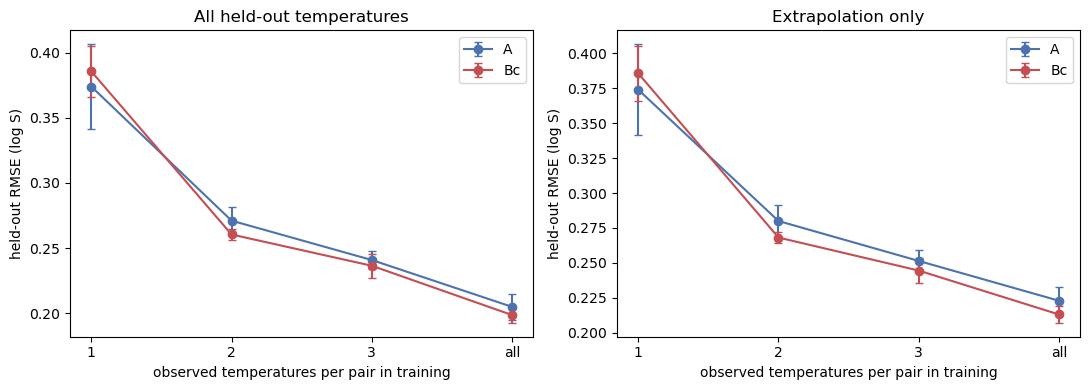

In [15]:
x = np.arange(len(order))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for metric, axi, title in [("test_rmse", ax[0], "All held-out temperatures"),
                           ("rmse_extrap", ax[1], "Extrapolation only")]:
    for kind, colour in [("A", "#4C72B0"), ("Bc", "#C44E52")]:
        m = [res[(res.n_T == n) & (res.model == kind)][metric].mean() for n in order]
        e = [res[(res.n_T == n) & (res.model == kind)][metric].std() for n in order]
        axi.errorbar(x, m, yerr=e, marker="o", capsize=3, label=kind, color=colour)
    axi.set_xticks(x); axi.set_xticklabels(order)
    axi.set_xlabel("observed temperatures per pair in training")
    axi.set_ylabel("held-out RMSE (log S)")
    axi.set_title(title); axi.legend()

fig.tight_layout()
fig.savefig(RES / "fig09_temperature_sparsity.png", dpi=140)
plt.show()

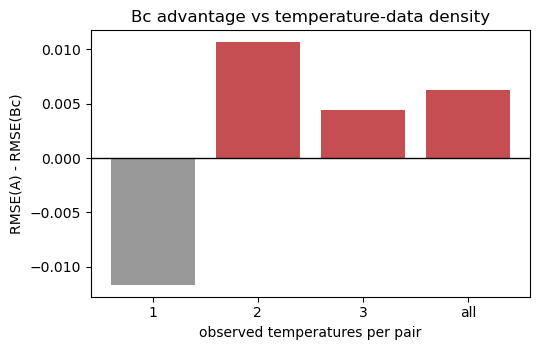

In [16]:
# Does the gap widen as temperature data get sparser?
gap = (paired.groupby("n_T")["diff"].mean() * -1).reindex(order)   # positive = Bc ahead
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar(x, gap.to_numpy(), color=["#C44E52" if v > 0 else "#999999" for v in gap])
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_xlabel("observed temperatures per pair")
ax.set_ylabel("RMSE(A) - RMSE(Bc)")
ax.set_title("Bc advantage vs temperature-data density")
fig.tight_layout()
fig.savefig(RES / "fig09_gap.png", dpi=140)
plt.show()

### Does `b_scale` drive the result?

At `n_T = 1` the slope scale is not estimable from training data and we
substituted 1382 K. The check below retrains that condition with deliberately
different constants to measure the sensitivity.

In [17]:
check = []
tr_rows = train_sets[(1, 0)]
idx = split_indices(tr_rows, seed=0)
for bs in [500.0, 1382.0, 3000.0]:
    m, _, _ = train_one("Bc", "tsparse_bscheck", 42, device="cpu",
                        b_scale=bs, verbose=False, split_indices=idx)
    check.append({"b_scale": bs, "test_rmse": round(m["test"]["rmse"], 4)})
pd.DataFrame(check)

,b_scale,test_rmse
0,500.0,0.3670
1,1382.0,0.3780
2,3000.0,0.3924


### Conclusion

The Van't Hoff bias does not reduce the amount of temperature data required.

| observed T per pair | Bc - A | Bc better (of 9 runs) |
|---|---:|---:|
| 1 | +0.0116 | 3 |
| 2 | -0.0106 | 8 |
| 3 | -0.0044 | 6 |
| all | -0.0063 | 6 |

The advantage is largest at two observed temperatures and reverses at one - the
regime where data efficiency would matter most.

With a single temperature per pair there is no within-pair temperature variation
anywhere in training. Bc must still commit to a slope predicted from chemistry
alone, and a wrong slope is multiplied by `z` and added to every prediction.
Model A can effectively ignore temperature, which is close to correct when no
slope is identifiable. The `b_scale` check supports this: shrinking the scale
from 1382 K to 500 K, toward a temperature-blind model, improves RMSE from 0.378
to 0.367.

That sensitivity (0.025) is about twice the +0.0116 gap, and the run-to-run
spread at one temperature is 0.030, so this is best read as no advantage at
`n_T = 1` rather than Bc being worse.

Splitting the test rows shows the benefit is an extrapolation effect only:

| n_T | extrapolation Bc - A | interpolation Bc - A |
|---|---:|---:|
| 2 | -0.0118 | -0.0047 |
| 3 | -0.0069 | +0.0027 |
| all | -0.0098 | -0.0008 |

Interpolation is a near-tie throughout. Bc constrains behaviour outside the
observed temperature range at every data density once at least two temperatures
per pair exist, but the benefit does not grow as data thin out.

In [18]:
best = paired.groupby("n_T")["diff"].mean().reindex(order)
print("mean Bc - A by temperature budget (negative = Bc better):")
for n in order:
    print(f"  n_T={n:>3}: {best[n]:+.4f}")
print()
print(f"sparsest (n_T=1): {best['1']:+.4f}      densest (all): {best['all']:+.4f}")
print(f"change in Bc advantage from sparse to dense: {(-best['1']) - (-best['all']):+.4f} log S")

mean Bc - A by temperature budget (negative = Bc better):
  n_T=  1: +0.0116
  n_T=  2: -0.0106
  n_T=  3: -0.0044
  n_T=all: -0.0063

sparsest (n_T=1): +0.0116      densest (all): -0.0063
change in Bc advantage from sparse to dense: -0.0179 log S
